In [1]:
from common import *
from database import get_engine, run_query
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

order_f = run_query("SELECT * FROM order_features")
customer_f = run_query("SELECT * FROM customer_features")
seller_f = run_query("SELECT * FROM seller_features")
reviews = run_query("SELECT order_id, review_score FROM order_reviews")
products = run_query("""
    SELECT p.product_id, t.product_category_name_english AS category
    FROM products p
    JOIN product_category_translation t
      ON t.product_category_name = p.product_category_name
""")
items = run_query("SELECT order_id, product_id, price FROM order_items")

order_f["order_purchase_timestamp"] = pd.to_datetime(order_f["order_purchase_timestamp"])

# join reviews onto orders once, reused everywhere below
order_rev = order_f.merge(reviews, on="order_id", how="inner")
print(order_f.shape, customer_f.shape, seller_f.shape, order_rev.shape)

(99441, 12) (95560, 7) (3095, 4) (98673, 13)


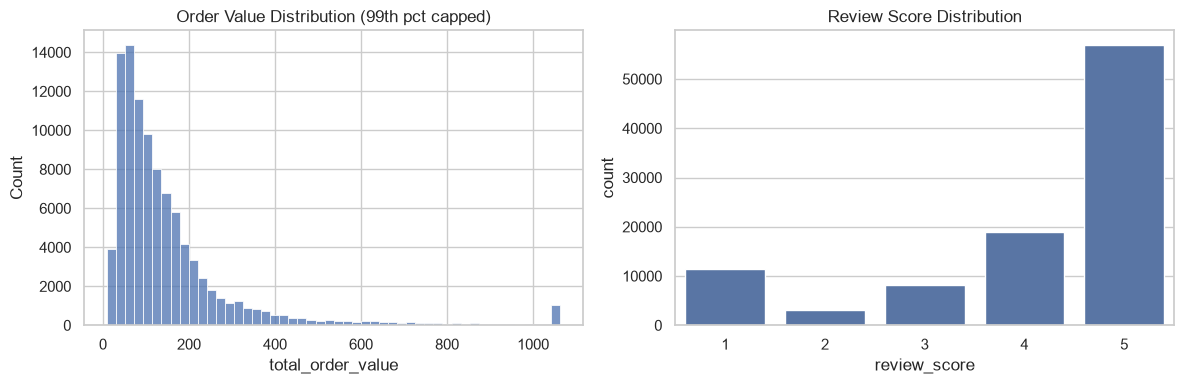

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(order_f["total_order_value"].clip(upper=order_f["total_order_value"].quantile(0.99)),
             bins=50, ax=axes[0])
axes[0].set_title("Order Value Distribution (99th pct capped)")

sns.countplot(x="review_score", data=reviews, ax=axes[1], order=[1,2,3,4,5])
axes[1].set_title("Review Score Distribution")
plt.tight_layout(); plt.show()

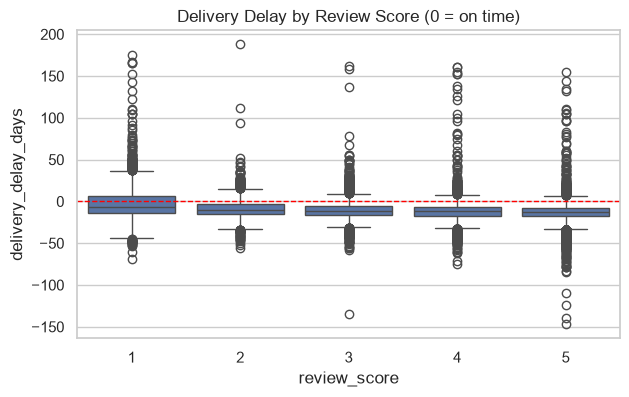

review_score
1    -4.043827
2    -8.630264
3   -10.760515
4   -12.385642
5   -13.384465
Name: delivery_delay_days, dtype: float64

In [3]:
delayed = order_rev.dropna(subset=["delivery_delay_days"])
plt.figure(figsize=(7, 4))
sns.boxplot(x="review_score", y="delivery_delay_days", data=delayed, order=[1,2,3,4,5])
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Delivery Delay by Review Score (0 = on time)")
plt.show()

delayed.groupby("review_score")["delivery_delay_days"].mean()

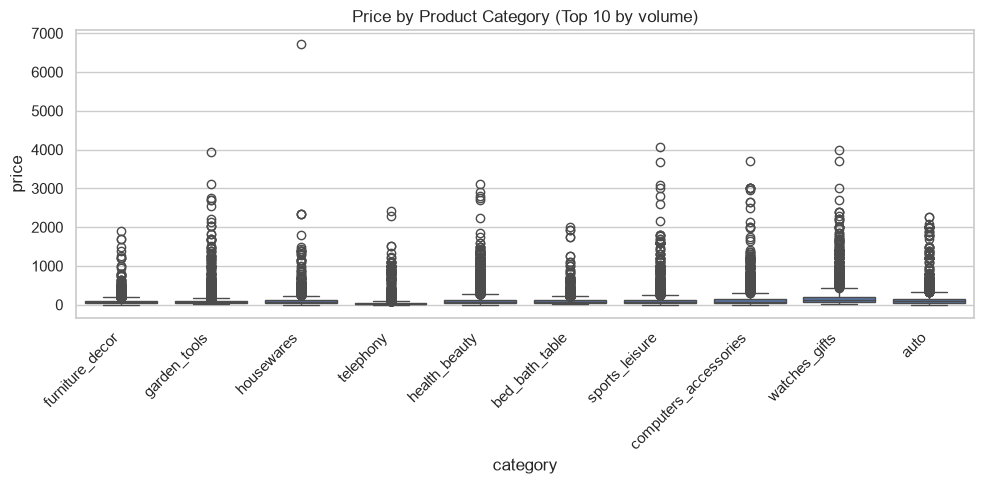

In [4]:
items_cat = items.merge(products, on="product_id", how="inner")
top_categories = items_cat["category"].value_counts().head(10).index
subset = items_cat[items_cat["category"].isin(top_categories)]

plt.figure(figsize=(10, 5))
sns.boxplot(x="category", y="price", data=subset)
plt.xticks(rotation=45, ha="right")
plt.title("Price by Product Category (Top 10 by volume)")
plt.tight_layout(); plt.show()

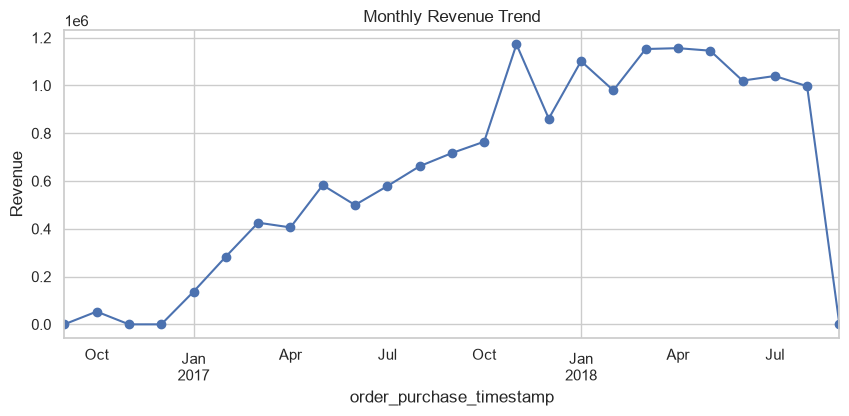

In [6]:
monthly = (order_f[order_f["order_status"] != "canceled"]
           .set_index("order_purchase_timestamp")
           .resample("ME")["total_order_value"].sum())

plt.figure(figsize=(10, 4))
monthly.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

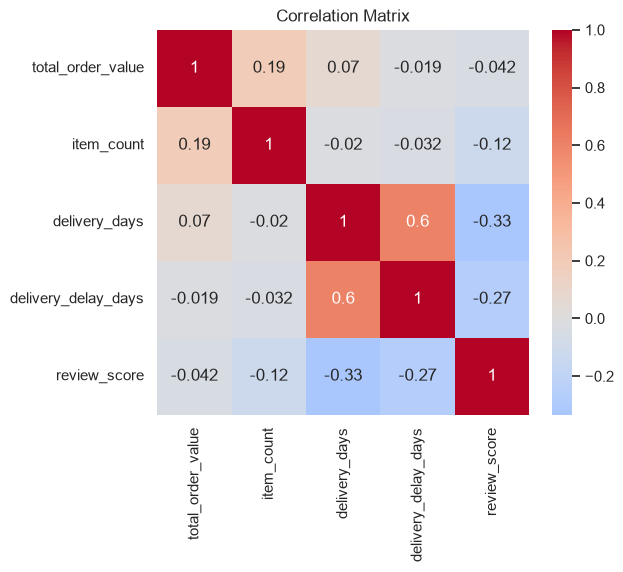

In [5]:
num_cols = ["total_order_value", "item_count", "delivery_days", "delivery_delay_days"]
corr_df = order_rev[num_cols + ["review_score"]].dropna()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

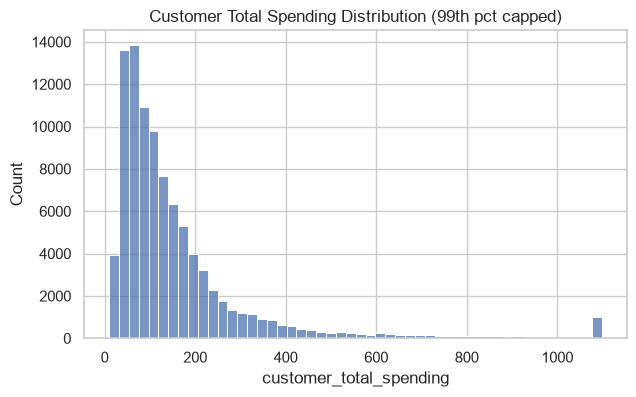

Repeat customer rate: 0.031


In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(customer_f["customer_total_spending"].clip(
    upper=customer_f["customer_total_spending"].quantile(0.99)), bins=50)
plt.title("Customer Total Spending Distribution (99th pct capped)")
plt.show()

print("Repeat customer rate:", customer_f["is_repeat_customer"].mean().round(3))